# Simple RNN Sequence Classification (IMDB)
Ready for Google Colab.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [2]:
vocab_size=10000
max_length=200
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=vocab_size)
x_train=pad_sequences(x_train,maxlen=max_length)
x_test=pad_sequences(x_test,maxlen=max_length)
print(x_train.shape,x_test.shape)

(25000, 200) (25000, 200)


In [3]:
print(type(x_test))

<class 'numpy.ndarray'>


In [4]:
model=Sequential([
    Embedding(vocab_size,64,input_length=max_length),
    SimpleRNN(64),
    Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

C:\Users\Pranav\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
history=model.fit(x_train,y_train,epochs=3,batch_size=128,validation_split=0.2)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.5921 - loss: 0.6539 - val_accuracy: 0.6560 - val_loss: 0.6105
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.8101 - loss: 0.4320 - val_accuracy: 0.7456 - val_loss: 0.5127
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9268 - loss: 0.1982 - val_accuracy: 0.8098 - val_loss: 0.4740


In [6]:
loss,acc=model.evaluate(x_test,y_test)
print("Test Accuracy:",acc)
pred=(model.predict(x_test)>0.5).astype(int)
print("Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred))
print("Recall:",recall_score(y_test,pred))
print("F1:",f1_score(y_test,pred))
print("Confusion Matrix\n",confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8144 - loss: 0.4587
Test Accuracy: 0.8143600225448608
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step
Accuracy: 0.81436
Precision: 0.8004434589800443
Recall: 0.83752
F1: 0.8185621017240705
Confusion Matrix
 [[ 9890  2610]
 [ 2031 10469]]
              precision    recall  f1-score   support

           0       0.83      0.79      0.81     12500
           1       0.80      0.84      0.82     12500

    accuracy                           0.81     25000
   macro avg       0.82      0.81      0.81     25000
weighted avg       0.82      0.81      0.81     25000



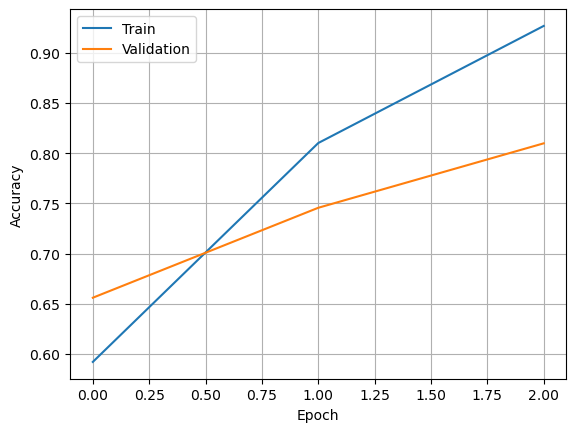

In [7]:
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

In [28]:
word_index = imdb.get_word_index()

review = input("Review: ").lower()
seq = [word_index.get(w.lower(), 2) + 3 for w in review.split()]
pred = model.predict(pad_sequences([seq], maxlen=max_length), verbose=0)[0][0]

print("Positive" if pred >= 0.5 else "Negative")

Review:  worse


Positive
